# Day 05｜Quantum Fundamentals：從資料到量測輸出

整合 Day 2 的 state vector、Day 3 的 rotation gates、Day 4 的 Bell circuit。今天完成 **forward pass**，不進行模型訓練。請選擇專案 `.venv/bin/python` 為 Notebook kernel，依序 Run All。

In [1]:
from pathlib import Path
import sys
import numpy as np

root = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "articles/day05/pipeline.py").exists()), None)
if root is None:
    raise RuntimeError("請從 repository 根目錄或 notebooks/ 開啟 Notebook")
sys.path.insert(0, str(root))
sys.path.insert(0, str(root / "articles/day05"))
from articles.day03.quantum_gates import H, KET_ZERO, apply_gate, probabilities
from articles.day04.bell_state import bell_state, exact_probabilities
from pipeline import encode, state_vector, prediction_from_counts, run_pipeline
print("Python:", sys.version.split()[0], "NumPy:", np.__version__)

Python: 3.12.7 NumPy: 2.2.6


## 1. 先看完整架構

輸入 → encoding → circuit → measurement → classical post-processing → metrics。未來才加入 trainable parameters 與 optimizer 回饋。

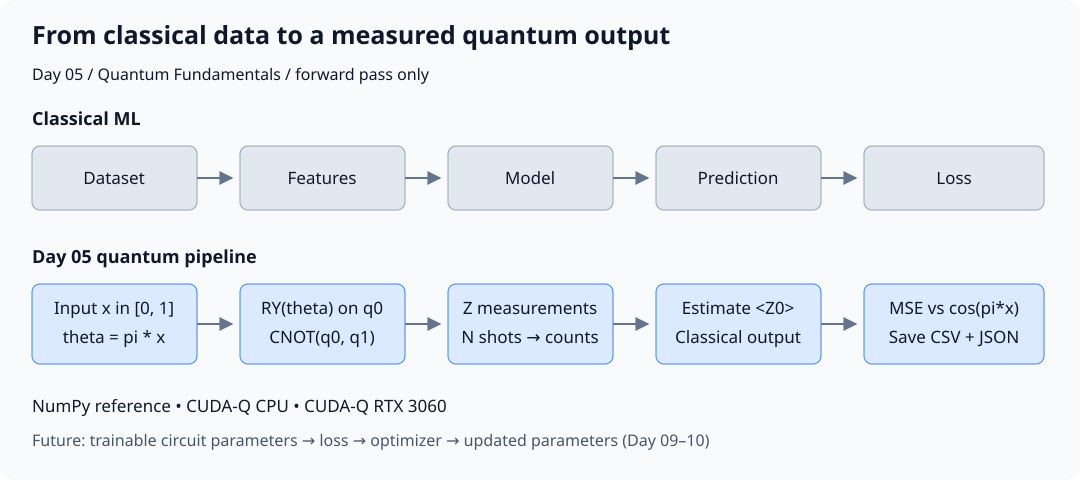

In [2]:
from IPython.display import SVG, display
display(SVG(filename=str(root / "figures/day05_pipeline.svg")))

## 2. 回顧 Day 2–3：Amplitude 與 Probability

H 對 `|0⟩` 產生等幅疊加；probability 是 amplitude 的絕對值平方。

In [3]:
plus = apply_gate(H, KET_ZERO)
print("amplitudes:", plus)
print("Z probabilities:", probabilities(plus))
np.testing.assert_allclose(probabilities(plus), [0.5, 0.5], atol=1e-12)

amplitudes: [0.70710678+0.j 0.70710678+0.j]
Z probabilities: [0.5 0.5]


## 3. 回顧 Day 4：Bell State 與經典混合態

兩者 Z 分布相同；在這兩個已知準備之間，X 基底能看出差異。

In [4]:
print("Bell amplitudes:", bell_state())
for name in ("bell", "mixture"):
    for basis in ("Z", "X"):
        print(name, basis, exact_probabilities(name, basis))
np.testing.assert_allclose(exact_probabilities("mixture", "X"), [0.25]*4, atol=1e-12)

Bell amplitudes: [0.70710678+0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]
bell Z [0.5 0.  0.  0.5]
bell X [0.5 0.  0.  0.5]
mixture Z [0.5 0.  0.  0.5]
mixture X [0.25 0.25 0.25 0.25]


## 4. 輸入決定電路

設定 `theta = pi*x`，對 q0 施加 RY，再施加 CNOT。輸出純態為 `cos(theta/2)|00⟩ + sin(theta/2)|11⟩`。當 x=0.5，就回到 Day 4 的 Bell state。這裡 theta 是資料決定的角度，不是 optimizer 更新的權重。

In [5]:
x = 0.5
print("x:", x, "theta:", encode(x))
print("state:", state_vector(x))
np.testing.assert_allclose(state_vector(x), bell_state(), atol=1e-12)

x: 0.5 theta: 1.5707963267948966
state: [0.70710678+0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]


## 5. Counts 轉成 Classical Output

以 q0 的 Z observable 作輸出：首位 0 記 +1，首位 1 記 −1。一般公式須保留 01／10，不能假定任何電路都只有 00／11。

In [6]:
counts = {"00": 493, "01": 0, "10": 0, "11": 507}
print("Z0 estimate:", prediction_from_counts(counts))
assert abs(prediction_from_counts(counts) + 0.014) < 1e-12

Z0 estimate: -0.014


## 6. 完整 NumPy 前向實驗

9 個輸入、每個 1,000 shots、3 組 seed，共 27 筆。目標 cos(pi*x) 是已知解析式，用於驗證線性代數與抽樣，不是訓練／測試資料集。

In [7]:
numpy_rows, numpy_summary = run_pipeline("numpy")
print("records:", len(numpy_rows))
print("sampled MSE:", numpy_summary["sampled_mse"])
print("expected sampling MSE:", numpy_summary["expected_sampled_mse"])
print("constant-zero MSE:", numpy_summary["constant_zero_baseline_mse"])
print("analytic classical MSE:", numpy_summary["analytic_classical_reference_mse"])
assert len(numpy_rows) == 27

records: 27
sampled MSE: 0.00047116889712033863
expected sampling MSE: 0.00044444444444444447
constant-zero MSE: 0.5555555555555556
analytic classical MSE: 0.0


## 7. 同一流程交給 CUDA-Q CPU

Notebook 預設使用 qpp-cpu，方便在沒有 GPU 存取權限的環境重跑。GPU 版本由文章中的 CLI 指令執行，結果各自保存。

In [8]:
import cudaq
from cudaq_pipeline import encoded_pair
cudaq.set_target("qpp-cpu")
print(cudaq.draw(encoded_pair, float(np.pi/2), True))
cpu_rows, cpu_summary = run_pipeline("qpp-cpu")
print("CPU sampled MSE:", cpu_summary["sampled_mse"])
assert all(row["count_01"] + row["count_10"] == 0 for row in cpu_rows)
assert cpu_summary["sampled_mse"] < 0.01

     ╭───────────╮     
q0 : ┤ ry(1.571) ├──●──
     ╰───────────╯╭─┴─╮
q1 : ─────────────┤ x ├
                  ╰───╯



CPU sampled MSE: 0.00036460816231431774


## 8. 查看各輸入的輸出

以下只展示 seed 42；JSON 指標會聚合全部 3 組 seed。不要只挑單一 seed 宣稱模型效果。

In [9]:
print("x      target    sampled")
for row in cpu_rows:
    if row["repeat_seed"] == 42:
        print(f"{row['input']:.3f}  {row['target']: .5f}  {row['prediction']: .5f}")

x      target    sampled
0.000   1.00000   1.00000
0.125   0.92388   0.92200
0.250   0.70711   0.70200
0.375   0.38268   0.38400
0.500   0.00000  -0.00400
0.625  -0.38268  -0.36000
0.750  -0.70711  -0.67200
0.875  -0.92388  -0.92400
1.000  -1.00000  -1.00000


## 9. 暫存結果並驗證輸出契約

Notebook 使用暫存目錄示範保存，不覆蓋已提交的實驗結果。正式 CSV／JSON 由 pipeline.py 產生。

In [10]:
import json
import tempfile
from pipeline import write_results
with tempfile.TemporaryDirectory() as temporary:
    output = Path(temporary)
    write_results(cpu_rows, cpu_summary, output)
    saved = json.loads((output / "summary.json").read_text())
    assert saved["record_count"] == 27
    print("saved:", sorted(p.name for p in output.iterdir()))

saved: ['predictions.csv', 'summary.json']


## 10. 第一階段交付完成

- 理解 normalized state、unitary gate、tensor product 與 Bell state。
- 能把 classical input 帶入 circuit，將 counts 轉成 scalar output。
- 有 NumPy 參考、CUDA-Q 執行、測試及結果紀錄。
- 本例的解析 classical reference 已是精確答案；CNOT 也不是產生 Z0 輸出的必要條件。沒有因此得到 quantum advantage。

Day 6 整理環境與工具分工；Day 9–10 再引入可訓練參數與最佳化迴圈。

來源：[CUDA-Q Executing Kernels](https://nvidia.github.io/cuda-quantum/latest/using/examples/executing_kernels.html)；詳細推導與範圍見 [Day 05 文章](../articles/day05/README.md)。